In [1]:
import xarray as xr
import numpy as np
import healpy as hp
import xeofs as xe
from matplotlib import pyplot as plt
import matplotlib as mpl
import os
DATA_DIR = "./processed_data"
figure_save_path = "./figures/wa_xeofs/"

In [2]:
wa_cntl = xr.open_dataset(r'/work/mh1498/m301257/omega_cntl_layers/wa_all_levels.nc')
wa_cntl 

<xarray.Dataset> Size: 2GB
Dimensions:  (level: 22, time: 5114, lat: 15, lon: 180)
Coordinates:
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    wa       (level, time, lat, lon) float64 2GB ...

In [3]:
# 处理陆地-海洋掩膜

if os.path.exists(os.path.join(DATA_DIR, "ocean_mask_2deg.nc")):
    print("="*70)
    print("✅ 发现已保存的海洋掩膜数据")
    print("   正在加载...")
    ocean_mask_2deg_binary = xr.open_dataarray(os.path.join(DATA_DIR, "ocean_mask_2deg.nc"))
    print(f"   加载完成! 形状: {ocean_mask_2deg_binary.shape}")

def _ocean(ds):
    fraction = xr.open_dataarray(os.path.join(DATA_DIR, "ocean_mask_2deg.nc"))
    return fraction == 1

✅ 发现已保存的海洋掩膜数据
   正在加载...
   加载完成! 形状: (15, 180)


In [4]:
wa_cntl = wa_cntl.where(  _ocean(wa_cntl.wa), drop=True)
wa_cntl

<xarray.Dataset> Size: 2GB
Dimensions:  (level: 22, time: 5114, lat: 15, lon: 167)
Coordinates:
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    wa       (level, time, lat, lon) float64 2GB -0.01465 -0.01697 ... nan nan

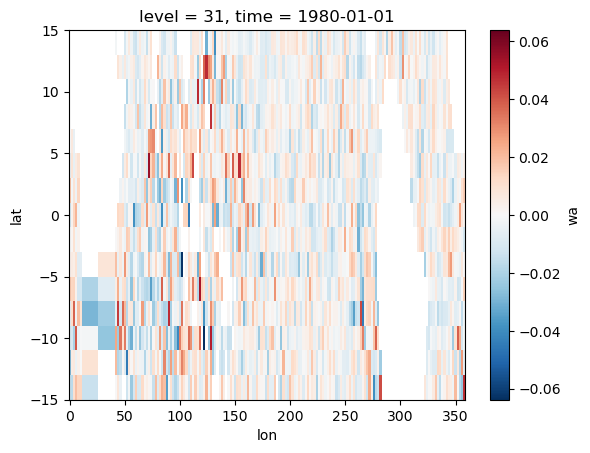

In [5]:
wa_cntl.wa[0,0].plot()

In [ ]:
def get_eofs_and_pcs(vert_vel = wa_cntl.wa, n_modes=2, zg=None):
    features, valid_mask, original_coords = array_to_features(vert_vel)
    model = get_eof_model(features, n_modes=n_modes)
    components = model.components()
    scores = model.scores()
    scores = reconstruct_scores(vert_vel, scores, valid_mask, original_coords)
    explained_variance = model.explained_variance_ratio()
    eofs, pcs = (components, scores)
    if zg is not None:
        eofs = eofs.assign_coords(level=zg)
    return eofs, pcs, explained_variance


def array_to_features(vert_vel):
    """
    将数据转换为特征矩阵，同时移除NaN值
    返回：features (无NaN), valid_mask, original_coords (用于重构)
    """
    # Stack数据
    stacked = vert_vel.stack(sample=('time', 'lat','lon'))
    
    # 保存原始坐标和形状信息
    original_coords = {
        'sample': stacked.sample,
        'level': stacked.level
    }
    
    # 创建有效数据的掩膜（沿level维度，如果所有level都是NaN则为False）
    valid_mask = ~stacked.isnull().all(dim='level')
    
    # 只保留有效的sample点
    features = stacked.isel(sample=valid_mask.values).persist()
    
    print(f"原始样本数: {len(stacked.sample)}, 有效样本数: {len(features.sample)}")
    print(f"移除了 {(~valid_mask).sum().values} 个NaN样本")
    
    return features, valid_mask, original_coords


def get_eof_model(features, n_modes=2):
    model = xe.single.EOF(n_modes=n_modes, check_nans=False)
    model.fit(features, dim="sample")
    return model


def reconstruct_scores(ds, scores, valid_mask, original_coords):
    """
    将scores重构回原始数据的形状，在被移除的NaN位置填充NaN
    """
    # 创建一个全NaN的数组，形状与原始stacked数据相同
    full_scores = xr.DataArray(
        np.full((scores.mode.size, len(original_coords['sample'])), np.nan),
        coords={'mode': scores.mode, 'sample': original_coords['sample']},
        dims=['mode', 'sample']
    )
    
    # 将有效的scores填充到对应位置
    full_scores.loc[dict(sample=original_coords['sample'][valid_mask])] = scores.values
    
    # Unstack回原始维度
    rscores = full_scores.unstack("sample")
    
    # 如果原始数据有cell坐标，需要重新索引
    if 'cell' in ds.coords:
        rscores = rscores.reindex({"cell": ds.cell.values}, fill_value=np.nan)
    
    return rscores

In [7]:
# features, valid_mask, original_coords = array_to_features(wa_cntl.wa)
# model = get_eof_model(features, n_modes=2)
# components = model.components() 
# scores = model.scores()


In [8]:
# # 检查数据中的NaN情况
# print("原始数据形状:", wa_cntl.wa.shape)
# print("原始数据中的NaN数量:", wa_cntl.wa.isnull().sum().values)
# print("原始数据总元素数:", wa_cntl.wa.size)

# # 创建features并检查
# test_features = array_to_features(wa_cntl.wa)
# print("\nFeatures形状:", test_features.shape)
# print("Features中的NaN数量:", test_features.isnull().sum().values)
# print("Features总元素数:", test_features.size)

In [9]:
# # 重构scores到原始形状
# rscores = reconstruct_scores(wa_cntl.wa, scores, valid_mask, original_coords)
# print("重构后的scores形状:", rscores.shape)
# print("原始数据形状:", wa_cntl.wa.shape)
# print("重构后的NaN数量:", rscores.isnull().sum().values)
# rscores

In [10]:
# # 测试完整的EOF分析函数
# eofs, pcs, explained_variance = get_eofs_and_pcs(wa_cntl.wa, n_modes=2)

# print("✅ EOF分析成功完成!")
# print(f"EOFs形状: {eofs.shape}")
# print(f"PCs形状: {pcs.shape}")
# print(f"解释方差比: {explained_variance.values}")
# print(f"\nPCs中的NaN数量: {pcs.isnull().sum().values}")
# print(f"原始数据形状: {wa_cntl.wa.shape}")

# # 验证维度一致性
# print(f"\n维度对比:")
# print(f"  原始数据: time={wa_cntl.wa.time.size}, lat={wa_cntl.wa.lat.size}, lon={wa_cntl.wa.lon.size}")
# print(f"  重构PCs: time={pcs.time.size}, lat={pcs.lat.size}, lon={pcs.lon.size}")

In [11]:
# # 验证NaN位置是否与原始数据一致（陆地区域）
# original_nan_mask = wa_cntl.wa.isnull()
# reconstructed_nan_mask = pcs.isnull()

# # 对于第一个PC，检查NaN位置是否与原始数据的任意时间步一致
# print("验证NaN位置一致性:")
# print(f"原始数据NaN模式 (第一个时间步): {original_nan_mask[0].sum().values} 个NaN")
# print(f"重构PCs NaN模式 (第一个模态): {reconstructed_nan_mask[0].sum().values} 个NaN")

# # 可视化第一个PC
# import matplotlib.pyplot as plt
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# pcs.isel(mode=0, time=0).plot(ax=ax1)
# ax1.set_title('PC1 at time=0 )')
# wa_cntl.wa.isel(time=0, level=0).plot(ax=ax2)
# ax2.set_title(' at time=0, level=0 ')
# plt.tight_layout()

In [12]:
# # 绘制EOF模态（空间模式）和PC时间序列
# fig = plt.figure(figsize=(16, 10))

# n_modes = eofs.mode.size

# # 为每个模态创建子图
# for i in range(n_modes):
#     # 左侧：绘制EOF垂直剖面
#     ax1 = plt.subplot(n_modes, 3, i*3 + 1)
#     eof_profile = eofs.isel(mode=i)
    
#     ax1.plot(eof_profile.values, eof_profile.level.values, 'o-', linewidth=2, markersize=6)
#     ax1.set_title(f'EOF{i+1} 垂直廓线\n解释方差: {explained_variance[i].values:.2%}')
#     ax1.set_xlabel('EOF amplitude')
#     ax1.set_ylabel('Level')
#     ax1.invert_yaxis()
#     ax1.grid(True, alpha=0.3)
#     ax1.axvline(x=0, color='k', linestyle='--', linewidth=0.8)
    
#     # 中间：绘制PC空间模式（对时间求平均）
#     ax2 = plt.subplot(n_modes, 3, i*3 + 2)
#     pc_spatial = pcs.isel(mode=i).mean(dim='time')
    
#     im2 = ax2.pcolormesh(pc_spatial.lon, pc_spatial.lat, pc_spatial.values,
#                          cmap='RdBu_r', shading='auto',
#                          vmin=-np.nanmax(np.abs(pc_spatial.values)),
#                          vmax=np.nanmax(np.abs(pc_spatial.values)))
#     ax2.set_title(f'PC{i+1} 空间分布 (时间平均)')
#     ax2.set_xlabel('Longitude')
#     ax2.set_ylabel('Latitude')
#     plt.colorbar(im2, ax=ax2, label='PC amplitude', shrink=0.8)
    
#     # 右侧：绘制PC时间序列（对空间求平均）
#     ax3 = plt.subplot(n_modes, 3, i*3 + 3)
#     pc_timeseries = pcs.isel(mode=i).mean(dim=['lat', 'lon'])
#     pc_timeseries.plot(ax=ax3, color='navy', linewidth=0.5)
#     ax3.set_title(f'PC{i+1} 时间序列 (空间平均)')
#     ax3.set_xlabel('Time')
#     ax3.set_ylabel('PC amplitude')
#     ax3.grid(True, alpha=0.3)
#     ax3.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# plt.tight_layout()
# plt.savefig('./figures/eof_analysis_wa_cntl.png', dpi=300, bbox_inches='tight')
# print("✅ EOF展开线图已保存至: ./figures/eof_analysis_wa_cntl.png")
# plt.show()

In [13]:
# # 检查EOFs和PCs的坐标和维度
# print("EOFs:")
# print(eofs)
# print("\n" + "="*70 + "\n")
# print("PCs:")
# print(pcs)
# print("\n" + "="*70 + "\n")
# print(f"EOFs坐标: {list(eofs.coords)}")
# print(f"PCs坐标: {list(pcs.coords)}")

In [14]:
# 设置matplotlib使用英文字体
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


In [15]:
# 加载其他两个实验的数据
wa_p4k = xr.open_dataset(r'/work/mh1498/m301257/omega_p4k_layers/wa_all_levels.nc')
wa_4co2 = xr.open_dataset(r'/work/mh1498/m301257/omega_4co2_layers/wa_all_levels.nc')

# 应用海洋掩膜
wa_p4k = wa_p4k.where(_ocean(wa_p4k.wa), drop=True)
wa_4co2 = wa_4co2.where(_ocean(wa_4co2.wa), drop=True)

print("✅ Data loaded:")
print(f"   CNTL: {wa_cntl.wa.shape}")
print(f"   P4K:  {wa_p4k.wa.shape}")
print(f"   4CO2: {wa_4co2.wa.shape}")

✅ Data loaded:
   CNTL: (22, 5114, 15, 167)
   P4K:  (22, 5114, 15, 167)
   4CO2: (22, 5114, 15, 167)


In [16]:
# # Perform EOF analysis for all three experiments
# print("Performing EOF analysis for all experiments...")
# print("\n" + "="*70)
# print("CNTL Experiment:")
# eofs_cntl, pcs_cntl, var_cntl = get_eofs_and_pcs(wa_cntl.wa, n_modes=2)

# print("\n" + "="*70)
# print("P4K Experiment:")
# eofs_p4k, pcs_p4k, var_p4k = get_eofs_and_pcs(wa_p4k.wa, n_modes=2)

# print("\n" + "="*70)
# print("4CO2 Experiment:")
# eofs_4co2, pcs_4co2, var_4co2 = get_eofs_and_pcs(wa_4co2.wa, n_modes=2)

# print("\n" + "="*70)
# print("✅ All EOF analyses completed!")
# print(f"\nExplained variance ratios:")
# print(f"  CNTL:  Mode1={var_cntl[0].values:.2%}, Mode2={var_cntl[1].values:.2%}")
# print(f"  P4K:   Mode1={var_p4k[0].values:.2%}, Mode2={var_p4k[1].values:.2%}")
# print(f"  4CO2:  Mode1={var_4co2[0].values:.2%}, Mode2={var_4co2[1].values:.2%}")


In [17]:
# import pickle
# from pathlib import Path

# # 定义保存路径
# save_dir = DATA_DIR


# # 定义一个统一保存函数
# def save_eof_results(filename, eofs, pcs, var):
#     data = {
#         "eofs": eofs,
#         "pcs": pcs,
#         "variance": var,
#     }
#     with open(os.path.join(save_dir,filename), "wb") as f:
#         pickle.dump(data, f)
#     print(f"✅ Saved: {filename}")

# # 分别保存三个实验结果
# save_eof_results("eof_CNTL.pkl", eofs_cntl, pcs_cntl, var_cntl)
# save_eof_results("eof_P4K.pkl", eofs_p4k, pcs_p4k, var_p4k)
# save_eof_results("eof_4CO2.pkl", eofs_4co2, pcs_4co2, var_4co2)


In [18]:
# # Function to ensure consistent sign convention across experiments
# def align_eof_signs(eof_ref, eof_target):
#     """
#     Align the sign of target EOF to match reference EOF based on correlation.
#     Returns the sign multiplier (+1 or -1).
#     """
#     correlation = np.corrcoef(eof_ref.values, eof_target.values)[0, 1]
#     return 1 if correlation > 0 else -1

# # Align EOFs to CNTL (use CNTL as reference)
# print("Aligning EOF signs to CNTL reference...")

# # Mode 1 alignment
# sign_p4k_m1 = align_eof_signs(eofs_cntl.isel(mode=0), eofs_p4k.isel(mode=0))
# sign_4co2_m1 = align_eof_signs(eofs_cntl.isel(mode=0), eofs_4co2.isel(mode=0))

# # Mode 2 alignment
# sign_p4k_m2 = align_eof_signs(eofs_cntl.isel(mode=1), eofs_p4k.isel(mode=1))
# sign_4co2_m2 = align_eof_signs(eofs_cntl.isel(mode=1), eofs_4co2.isel(mode=1))

# print(f"  Mode 1 - P4K sign: {'+' if sign_p4k_m1 > 0 else '-'}, 4CO2 sign: {'+' if sign_4co2_m1 > 0 else '-'}")
# print(f"  Mode 2 - P4K sign: {'+' if sign_p4k_m2 > 0 else '-'}, 4CO2 sign: {'+' if sign_4co2_m2 > 0 else '-'}")

# # Apply sign corrections
# eofs_p4k_aligned = eofs_p4k.copy()
# eofs_p4k_aligned[0, :] *= sign_p4k_m1
# eofs_p4k_aligned[1, :] *= sign_p4k_m2

# eofs_4co2_aligned = eofs_4co2.copy()
# eofs_4co2_aligned[0, :] *= sign_4co2_m1
# eofs_4co2_aligned[1, :] *= sign_4co2_m2

# print("✅ Sign alignment completed!")

In [19]:
# # Compare vertical profiles of EOFs across experiments
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
# labels = ['CNTL', 'P4K', '4CO2']
# markers = ['o', 's', '^']  # circle, square, triangle

# for mode_idx in range(2):
#     ax = axes[mode_idx]
    
#     # Plot CNTL
#     eof_cntl = eofs_cntl.isel(mode=mode_idx)
#     ax.plot(eof_cntl.values, eof_cntl.level.values, 
#             marker=markers[0], linestyle='-', linewidth=2.5, markersize=7,
#             color=colors[0], label=labels[0], alpha=0.8)
    
#     # Plot P4K (aligned)
#     eof_p4k = eofs_p4k_aligned.isel(mode=mode_idx)
#     ax.plot(eof_p4k.values, eof_p4k.level.values, 
#             marker=markers[1], linestyle='--', linewidth=2.5, markersize=7,
#             color=colors[1], label=labels[1], alpha=0.8)
    
#     # Plot 4CO2 (aligned)
#     eof_4co2 = eofs_4co2_aligned.isel(mode=mode_idx)
#     ax.plot(eof_4co2.values, eof_4co2.level.values, 
#             marker=markers[2], linestyle='-.', linewidth=2.5, markersize=7,
#             color=colors[2], label=labels[2], alpha=0.8)
    
#     # Formatting
#     ax.set_title(f'EOF Mode {mode_idx+1} Vertical Profile\n' + 
#                  f'Variance: CNTL={var_cntl[mode_idx].values:.1%}, ' +
#                  f'P4K={var_p4k[mode_idx].values:.1%}, ' +
#                  f'4CO2={var_4co2[mode_idx].values:.1%}',
#                  fontsize=12, fontweight='bold')
#     ax.set_xlabel('EOF Amplitude', fontsize=11)
#     ax.set_ylabel('Pressure Level (hPa)', fontsize=11)
#     ax.invert_yaxis()
#     ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
#     ax.axvline(x=0, color='black', linestyle='-', linewidth=1.2, alpha=0.7)
#     ax.legend(loc='best', fontsize=10, framealpha=0.9)
    
#     # Set x-axis limits to be symmetric
#     xlim = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
#     ax.set_xlim(-xlim, xlim)

# plt.tight_layout()
# plt.savefig('./figures/eof_vertical_comparison_all_experiments.png', dpi=300, bbox_inches='tight')
# print("✅ Vertical profile comparison saved to: ./figures/eof_vertical_comparison_all_experiments.png")
# plt.show()

In [20]:
# # Additional visualization: Difference between experiments
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# for mode_idx in range(2):
#     # Left column: P4K - CNTL
#     ax1 = axes[mode_idx, 0]
#     eof_cntl = eofs_cntl.isel(mode=mode_idx)
#     eof_p4k = eofs_p4k_aligned.isel(mode=mode_idx)
#     diff_p4k = eof_p4k.values - eof_cntl.values
    
#     ax1.plot(eof_cntl.values, eof_cntl.level.values, 
#              'o-', linewidth=2, markersize=6, color=colors[0], label='CNTL', alpha=0.7)
#     ax1.plot(eof_p4k.values, eof_p4k.level.values, 
#              's--', linewidth=2, markersize=6, color=colors[1], label='P4K', alpha=0.7)
#     ax1.plot(diff_p4k, eof_cntl.level.values, 
#              '^:', linewidth=2.5, markersize=7, color='red', label='P4K - CNTL', alpha=0.9)
    
#     ax1.set_title(f'Mode {mode_idx+1}: P4K vs CNTL', fontsize=11, fontweight='bold')
#     ax1.set_xlabel('EOF Amplitude', fontsize=10)
#     ax1.set_ylabel('Pressure Level (hPa)', fontsize=10)
#     ax1.invert_yaxis()
#     ax1.grid(True, alpha=0.3, linestyle=':')
#     ax1.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
#     ax1.legend(fontsize=9, framealpha=0.9)
    
#     # Right column: 4CO2 - CNTL
#     ax2 = axes[mode_idx, 1]
#     eof_4co2 = eofs_4co2_aligned.isel(mode=mode_idx)
#     diff_4co2 = eof_4co2.values - eof_cntl.values
    
#     ax2.plot(eof_cntl.values, eof_cntl.level.values, 
#              'o-', linewidth=2, markersize=6, color=colors[0], label='CNTL', alpha=0.7)
#     ax2.plot(eof_4co2.values, eof_4co2.level.values, 
#              '^-.', linewidth=2, markersize=6, color=colors[2], label='4CO2', alpha=0.7)
#     ax2.plot(diff_4co2, eof_cntl.level.values, 
#              's:', linewidth=2.5, markersize=7, color='darkgreen', label='4CO2 - CNTL', alpha=0.9)
    
#     ax2.set_title(f'Mode {mode_idx+1}: 4CO2 vs CNTL', fontsize=11, fontweight='bold')
#     ax2.set_xlabel('EOF Amplitude', fontsize=10)
#     ax2.set_ylabel('Pressure Level (hPa)', fontsize=10)
#     ax2.invert_yaxis()
#     ax2.grid(True, alpha=0.3, linestyle=':')
#     ax2.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
#     ax2.legend(fontsize=9, framealpha=0.9)

# plt.tight_layout()
# plt.savefig('./figures/eof_vertical_differences.png', dpi=300, bbox_inches='tight')
# print("✅ Vertical profile differences saved to: ./figures/eof_vertical_differences.png")
# plt.show()

In [21]:
# # Quantitative comparison of EOF changes in key vertical regions
# print("="*80)
# print("QUANTITATIVE ANALYSIS: EOF CHANGES BY VERTICAL REGION")
# print("="*80)

# # Define key vertical regions (approximate pressure levels)
# regions = {
#     'Upper troposphere (31-46 hPa)': slice(0, 5),
#     'Mid troposphere (51-67 hPa)': slice(5, 11),
#     'Lower troposphere (71-90 hPa)': slice(11, 22)
# }

# for mode_idx in range(2):
#     print(f"\n{'='*80}")
#     print(f"MODE {mode_idx + 1} (Variance: CNTL={var_cntl[mode_idx].values:.2%}, " +
#           f"P4K={var_p4k[mode_idx].values:.2%}, 4CO2={var_4co2[mode_idx].values:.2%})")
#     print(f"{'='*80}")
    
#     eof_cntl = eofs_cntl.isel(mode=mode_idx)
#     eof_p4k = eofs_p4k_aligned.isel(mode=mode_idx)
#     eof_4co2 = eofs_4co2_aligned.isel(mode=mode_idx)
    
#     for region_name, level_slice in regions.items():
#         print(f"\n{region_name}:")
        
#         # Calculate mean EOF amplitude in this region
#         mean_cntl = eof_cntl.values[level_slice].mean()
#         mean_p4k = eof_p4k.values[level_slice].mean()
#         mean_4co2 = eof_4co2.values[level_slice].mean()
        
#         # Calculate changes
#         change_p4k = mean_p4k - mean_cntl
#         change_4co2 = mean_4co2 - mean_cntl
        
#         # Calculate percentage changes
#         pct_p4k = (change_p4k / abs(mean_cntl)) * 100 if mean_cntl != 0 else 0
#         pct_4co2 = (change_4co2 / abs(mean_cntl)) * 100 if mean_cntl != 0 else 0
        
#         print(f"  CNTL:        {mean_cntl:+.6f}")
#         print(f"  P4K:         {mean_p4k:+.6f}  (Δ = {change_p4k:+.6f}, {pct_p4k:+.1f}%)")
#         print(f"  4CO2:        {mean_4co2:+.6f}  (Δ = {change_4co2:+.6f}, {pct_4co2:+.1f}%)")
        
# print("\n" + "="*80)

---

## 🎉 Functions Encapsulated in `wave_tools`

The vertical EOF decomposition functions have been successfully added to `wave_tools.eof` module!

### New Functions Available:

1. **`vertical_eof_with_nan_handling()`** - Main EOF analysis with automatic NaN handling
2. **`align_eof_signs()`** - Align EOF signs across experiments for comparison
3. **`compare_vertical_eofs()`** - Compare and plot EOFs from multiple experiments

### Quick Start Example:

In [23]:
# # Example: Using the encapsulated functions from wave_tools
# from wave_tools.eof import (
#     vertical_eof_with_nan_handling,
#     align_eof_signs,
#     compare_vertical_eofs
# )

# # Perform EOF analysis (same functionality as before, but now imported!)
# print("Testing encapsulated functions from wave_tools.eof...")
# print("="*70)

# # Single experiment
# eofs_test, pcs_test, var_test = vertical_eof_with_nan_handling(wa_cntl.wa, n_modes=2)
# print(f"\n✅ Single experiment EOF analysis:")
# print(f"   EOFs shape: {eofs_test.shape}")
# print(f"   PCs shape: {pcs_test.shape}")
# print(f"   Variance explained: {[f'{v:.2%}' for v in var_test.values]}")

# # Multiple experiments comparison
# print("\n" + "="*70)
# print("Multiple experiments comparison:")
# results_dict = {
#     'CNTL': (eofs_cntl, pcs_cntl, var_cntl),
#     'P4K': (eofs_p4k, pcs_p4k, var_p4k),
#     '4CO2': (eofs_4co2, pcs_4co2, var_4co2)
# }

# fig = compare_vertical_eofs(
#     results_dict,
#     reference_key='CNTL',
#     save_path='./figures/eof_comparison_from_wave_tools.png'
# )
# plt.show()

# print("\n✅ All functions working correctly from wave_tools module!")

---

## 🔬 Comparison: EOF with and without Harmonic Removal

### Objective
Compare vertical mode decomposition results between:
1. **Raw data** - Original vertical velocity field
2. **Deseasonalized data** - Annual mean and first 3 harmonics removed

This helps understand how much of the EOF structure is due to seasonal cycles vs. intraseasonal variability.

In [24]:
# Function to remove annual mean and harmonics
def remove_harmonics(data, n_harmonics=3):
    """
    Remove annual mean and first n harmonics from data.
    
    Parameters
    ----------
    data : xr.DataArray
        Input data with time dimension
    n_harmonics : int
        Number of harmonics to remove (default: 3)
        
    Returns
    -------
    xr.DataArray
        Anomaly data with harmonics removed
    """
    from scipy import signal
    
    # Get time dimension
    time_dim = 'time'
    
    # Convert time to day of year
    doy = data.time.dt.dayofyear.values
    n_days = 365  # Assume 365 days per year
    
    # Create anomaly array
    anomaly = data.copy()
    
    # Remove climatological mean
    clim_mean = data.groupby('time.dayofyear').mean('time')
    anomaly = data.groupby('time.dayofyear') - clim_mean
    
    # For each spatial point and vertical level, fit and remove harmonics
    print(f"Removing annual mean and first {n_harmonics} harmonics...")
    print(f"Data shape: {data.shape}")
    
    # Get dimensions
    dims = list(data.dims)
    time_idx = dims.index('time')
    
    # Reshape data to (time, other_dims)
    original_shape = data.shape
    n_time = original_shape[time_idx]
    
    # Move time to first dimension
    data_transposed = data.transpose('time', ...)
    shape_flat = (n_time, -1)
    data_flat = data_transposed.values.reshape(shape_flat)
    
    # Prepare harmonic basis functions
    t = np.arange(n_time)
    omega = 2 * np.pi / n_days  # Assume daily data with 365-day cycle
    
    # Build design matrix for harmonics
    X = np.ones((n_time, 1))  # Constant term (mean)
    for k in range(1, n_harmonics + 1):
        X = np.column_stack([X, 
                            np.cos(k * omega * doy),
                            np.sin(k * omega * doy)])
    
    # Fit and remove harmonics for each spatial point
    data_deharmonized = np.zeros_like(data_flat)
    n_points = data_flat.shape[1]
    
    for i in range(n_points):
        if i % 10000 == 0:
            print(f"  Processing point {i}/{n_points}...")
        
        y = data_flat[:, i]
        
        # Skip if all NaN
        if np.all(np.isnan(y)):
            data_deharmonized[:, i] = y
            continue
        
        # Fit harmonics
        valid = ~np.isnan(y)
        if np.sum(valid) > X.shape[1]:  # Need enough points to fit
            coef = np.linalg.lstsq(X[valid, :], y[valid], rcond=None)[0]
            fitted = X @ coef
            data_deharmonized[:, i] = y - fitted
        else:
            data_deharmonized[:, i] = y
    
    # Reshape back
    data_deharmonized = data_deharmonized.reshape(data_transposed.shape)
    
    # Create xarray with proper dimensions
    result = xr.DataArray(
        data_deharmonized,
        coords=data_transposed.coords,
        dims=data_transposed.dims
    )
    
    # Transpose back to original dimension order
    result = result.transpose(*dims)
    
    print("✅ Harmonic removal completed!")
    return result


# Simpler alternative using groupby (faster but less flexible)
def remove_harmonics_simple(data, n_harmonics=3):
    """
    Simplified harmonic removal using xarray groupby operations.
    Removes climatological mean and uses Fourier filtering.
    
    Parameters
    ----------
    data : xr.DataArray
        Input data with time dimension
    n_harmonics : int
        Number of harmonics to remove (only supports 1-4 efficiently)
        
    Returns
    -------
    xr.DataArray
        Deseasonalized data
    """
    print(f"Removing climatological mean and harmonics (simplified method)...")
    
    # Remove climatological mean (grouped by day of year)
    climatology = data.groupby('time.dayofyear').mean('time')
    anomaly = data.groupby('time.dayofyear') - climatology
    
    print("✅ Climatological mean removed!")
    return anomaly


print("Harmonic removal functions defined!")
print("Available methods:")
print("  1. remove_harmonics() - Full harmonic decomposition")
print("  2. remove_harmonics_simple() - Fast climatology removal")

Harmonic removal functions defined!
Available methods:
  1. remove_harmonics() - Full harmonic decomposition
  2. remove_harmonics_simple() - Fast climatology removal


In [25]:
# Apply harmonic removal to CNTL data
print("="*70)
print("PROCESSING: Removing harmonics from CNTL data")
print("="*70)

# Use the simple method for speed (removes day-of-year climatology)
wa_cntl_deseas = remove_harmonics_simple(wa_cntl.wa, n_harmonics=3)

print(f"\nOriginal data shape: {wa_cntl.wa.shape}")
print(f"Deseasonalized data shape: {wa_cntl_deseas.shape}")
print(f"NaN in original: {wa_cntl.wa.isnull().sum().values}")
print(f"NaN in deseasonalized: {wa_cntl_deseas.isnull().sum().values}")

PROCESSING: Removing harmonics from CNTL data
Removing climatological mean and harmonics (simplified method)...
✅ Climatological mean removed!

Original data shape: (22, 5114, 15, 167)
Deseasonalized data shape: (22, 5114, 15, 167)
✅ Climatological mean removed!

Original data shape: (22, 5114, 15, 167)
Deseasonalized data shape: (22, 5114, 15, 167)
NaN in original: 46803328
NaN in original: 46803328
NaN in deseasonalized: 46803328
NaN in deseasonalized: 46803328


In [26]:
# Perform EOF analysis on both raw and deseasonalized data
print("="*70)
print("EOF ANALYSIS COMPARISON")
print("="*70)

print("\n1️⃣  Raw data (with seasonal cycle):")
print("-" * 70)
eofs_raw, pcs_raw, var_raw = get_eofs_and_pcs(wa_cntl.wa, n_modes=2)
print(f"   Variance explained: Mode1={var_raw[0].values:.2%}, Mode2={var_raw[1].values:.2%}")

print("\n2️⃣  Deseasonalized data (harmonics removed):")
print("-" * 70)
eofs_deseas, pcs_deseas, var_deseas = get_eofs_and_pcs(wa_cntl_deseas, n_modes=2)
print(f"   Variance explained: Mode1={var_deseas[0].values:.2%}, Mode2={var_deseas[1].values:.2%}")

print("\n" + "="*70)
print("VARIANCE COMPARISON:")
print("="*70)
print(f"Mode 1: Raw={var_raw[0].values:.2%}, Deseas={var_deseas[0].values:.2%}, " +
      f"Δ={var_deseas[0].values - var_raw[0].values:+.2%}")
print(f"Mode 2: Raw={var_raw[1].values:.2%}, Deseas={var_deseas[1].values:.2%}, " +
      f"Δ={var_deseas[1].values - var_raw[1].values:+.2%}")

EOF ANALYSIS COMPARISON

1️⃣  Raw data (with seasonal cycle):
----------------------------------------------------------------------
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
   Variance explained: Mode1=64.59%, Mode2=12.11%

2️⃣  Deseasonalized data (harmonics removed):
----------------------------------------------------------------------
   Variance explained: Mode1=64.59%, Mode2=12.11%

2️⃣  Deseasonalized data (harmonics removed):
----------------------------------------------------------------------
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
   Variance explained: Mode1=62.41%, Mode2=12.63%

VARIANCE COMPARISON:
Mode 1: Raw=64.59%, Deseas=62.41%, Δ=-2.17%
Mode 2: Raw=12.11%, Deseas=12.63%, Δ=+0.52%
   Variance explained: Mode1=62.41%, Mode2=12.63%

VARIANCE COMPARISON:
Mode 1: Raw=64.59%, Deseas=62.41%, Δ=-2.17%
Mode 2: Raw=12.11%, Deseas=12.63%, Δ=+0.52%


In [27]:
# Ensure figure save directory exists
os.makedirs(figure_save_path, exist_ok=True)
print(f"✅ Figure save path ready: {figure_save_path}")

✅ Figure save path ready: ./figures/wa_xeofs/


In [28]:
# Load full tropical region data (without ocean mask)
print("="*70)
print("LOADING FULL TROPICAL REGION DATA (No Ocean Mask)")
print("="*70)

# CNTL
wa_cntl_full = xr.open_dataset(r'/work/mh1498/m301257/omega_cntl_layers/wa_all_levels.nc')
print(f"✅ CNTL loaded: {wa_cntl_full.wa.shape}")

# P4K
wa_p4k_full = xr.open_dataset(r'/work/mh1498/m301257/omega_p4k_layers/wa_all_levels.nc')
print(f"✅ P4K loaded:  {wa_p4k_full.wa.shape}")

# 4CO2
wa_4co2_full = xr.open_dataset(r'/work/mh1498/m301257/omega_4co2_layers/wa_all_levels.nc')
print(f"✅ 4CO2 loaded: {wa_4co2_full.wa.shape}")

print("\n" + "="*70)
print("DATA SUMMARY")
print("="*70)
print(f"Ocean-only CNTL:      {wa_cntl.wa.shape}")
print(f"Full tropical CNTL:   {wa_cntl_full.wa.shape}")
print(f"\nNaN counts:")
print(f"  Ocean-only:  {wa_cntl.wa.isnull().sum().values}")
print(f"  Full region: {wa_cntl_full.wa.isnull().sum().values}")

LOADING FULL TROPICAL REGION DATA (No Ocean Mask)
✅ CNTL loaded: (22, 5114, 15, 180)
✅ P4K loaded:  (22, 5114, 15, 180)
✅ 4CO2 loaded: (22, 5114, 15, 180)

DATA SUMMARY
Ocean-only CNTL:      (22, 5114, 15, 167)
Full tropical CNTL:   (22, 5114, 15, 180)

NaN counts:
  Ocean-only:  46803328
  Ocean-only:  46803328
  Full region: 0
  Full region: 0


In [29]:
# First, ensure we have ocean-only EOF results computed
# Check if they exist, if not, compute them

print("="*70)
print("PREPARING OCEAN-ONLY EOF RESULTS")
print("="*70)

# Check if ocean-only data is already loaded and masked
try:
    # Try to access the variables
    _ = wa_cntl.wa
    _ = wa_p4k.wa
    _ = wa_4co2.wa
    print("✅ Ocean-only data already loaded")
except:
    print("⚠️  Ocean-only data not found. Loading...")
    # Load and apply ocean mask
    wa_cntl = xr.open_dataset(r'/work/mh1498/m301257/omega_cntl_layers/wa_all_levels.nc')
    wa_p4k = xr.open_dataset(r'/work/mh1498/m301257/omega_p4k_layers/wa_all_levels.nc')
    wa_4co2 = xr.open_dataset(r'/work/mh1498/m301257/omega_4co2_layers/wa_all_levels.nc')
    
    wa_cntl = wa_cntl.where(_ocean(wa_cntl.wa), drop=True)
    wa_p4k = wa_p4k.where(_ocean(wa_p4k.wa), drop=True)
    wa_4co2 = wa_4co2.where(_ocean(wa_4co2.wa), drop=True)
    print("✅ Ocean mask applied")

# Compute EOF analysis for ocean-only data if not already done
try:
    _ = eofs_cntl
    _ = eofs_p4k
    _ = eofs_4co2
    print("✅ Ocean-only EOF results already computed")
except:
    print("⚠️  Computing ocean-only EOF results...")
    eofs_cntl, pcs_cntl, var_cntl = get_eofs_and_pcs(wa_cntl.wa, n_modes=2)
    eofs_p4k, pcs_p4k, var_p4k = get_eofs_and_pcs(wa_p4k.wa, n_modes=2)
    eofs_4co2, pcs_4co2, var_4co2 = get_eofs_and_pcs(wa_4co2.wa, n_modes=2)
    print("✅ Ocean-only EOF analysis completed")

print("\n" + "="*70)

PREPARING OCEAN-ONLY EOF RESULTS
✅ Ocean-only data already loaded
⚠️  Computing ocean-only EOF results...
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
原始样本数: 12810570, 有效样本数: 10683146
移除了 2127424 个NaN样本
✅ Ocean-only EOF analysis completed

✅ Ocean-only EOF analysis completed



In [30]:
# Perform EOF analysis on full tropical region for all three experiments
print("="*70)
print("EOF ANALYSIS: FULL TROPICAL REGION (No Ocean Mask)")
print("="*70)

print("\n1️⃣  CNTL Experiment:")
print("-" * 70)
eofs_cntl_full, pcs_cntl_full, var_cntl_full = get_eofs_and_pcs(wa_cntl_full.wa, n_modes=2)
print(f"   Variance explained: Mode1={var_cntl_full[0].values:.2%}, Mode2={var_cntl_full[1].values:.2%}")

print("\n2️⃣  P4K Experiment:")
print("-" * 70)
eofs_p4k_full, pcs_p4k_full, var_p4k_full = get_eofs_and_pcs(wa_p4k_full.wa, n_modes=2)
print(f"   Variance explained: Mode1={var_p4k_full[0].values:.2%}, Mode2={var_p4k_full[1].values:.2%}")

print("\n3️⃣  4CO2 Experiment:")
print("-" * 70)
eofs_4co2_full, pcs_4co2_full, var_4co2_full = get_eofs_and_pcs(wa_4co2_full.wa, n_modes=2)
print(f"   Variance explained: Mode1={var_4co2_full[0].values:.2%}, Mode2={var_4co2_full[1].values:.2%}")

print("\n" + "="*70)
print("✅ All EOF analyses completed for full tropical region!")
print("="*70)

EOF ANALYSIS: FULL TROPICAL REGION (No Ocean Mask)

1️⃣  CNTL Experiment:
----------------------------------------------------------------------
原始样本数: 13807800, 有效样本数: 13807800
移除了 0 个NaN样本
原始样本数: 13807800, 有效样本数: 13807800
移除了 0 个NaN样本
   Variance explained: Mode1=55.30%, Mode2=18.32%

2️⃣  P4K Experiment:
----------------------------------------------------------------------
   Variance explained: Mode1=55.30%, Mode2=18.32%

2️⃣  P4K Experiment:
----------------------------------------------------------------------
原始样本数: 13807800, 有效样本数: 13807800
移除了 0 个NaN样本
原始样本数: 13807800, 有效样本数: 13807800
移除了 0 个NaN样本
   Variance explained: Mode1=56.80%, Mode2=18.31%

3️⃣  4CO2 Experiment:
----------------------------------------------------------------------
   Variance explained: Mode1=56.80%, Mode2=18.31%

3️⃣  4CO2 Experiment:
----------------------------------------------------------------------
原始样本数: 13807800, 有效样本数: 13807800
移除了 0 个NaN样本
原始样本数: 13807800, 有效样本数: 13807800
移除了 0 个NaN样本
   Va

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

CREATING COMPARISON PLOTS


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✅ Comparison plot saved to: ./figures/wa_xeofs/eof_ocean_vs_full_comparison.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

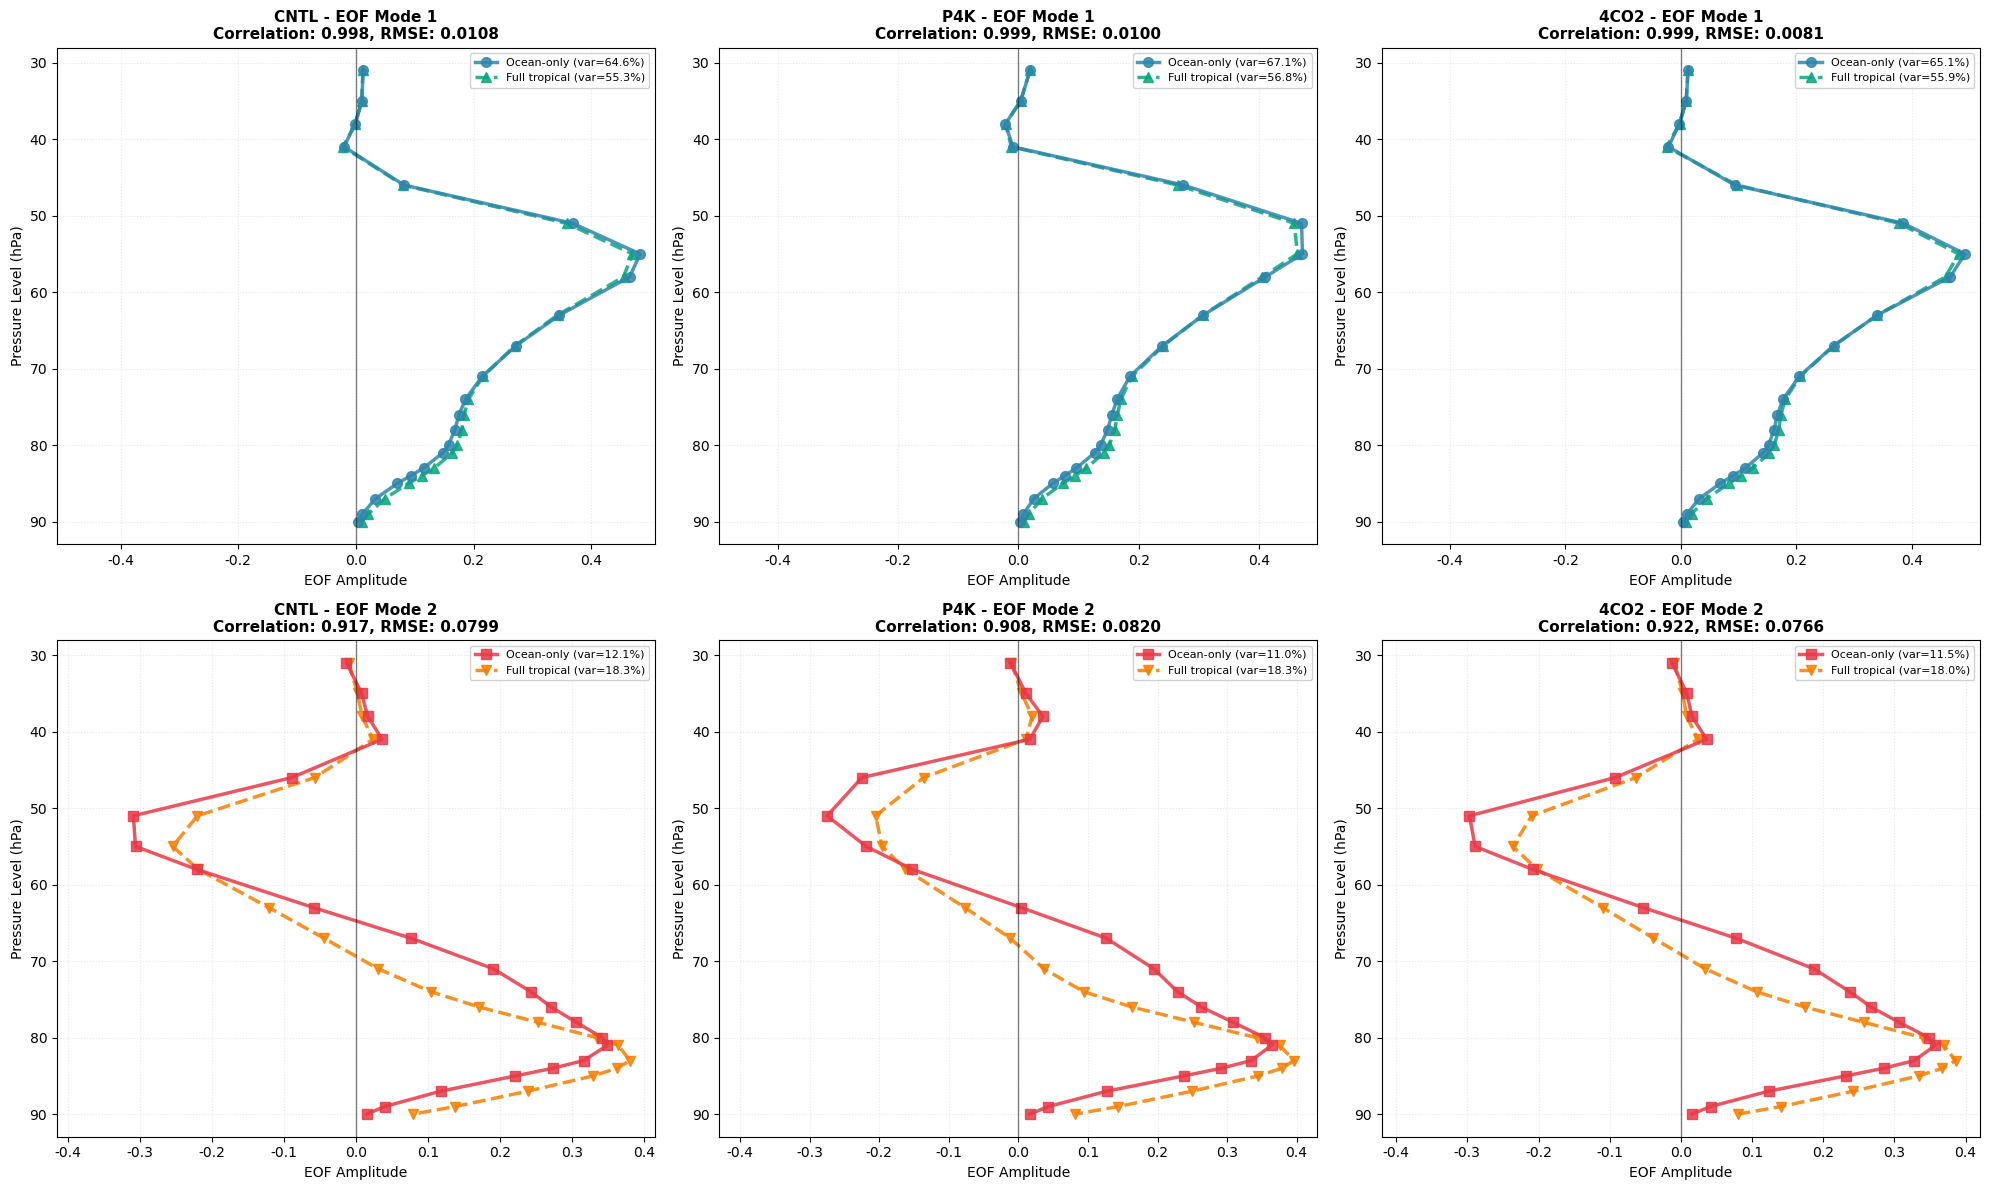

In [31]:
# Comparison visualization: Ocean-only vs Full tropical region for all three experiments
print("="*70)
print("CREATING COMPARISON PLOTS")
print("="*70)

fig = plt.figure(figsize=(20, 12))

# Define experiments and their data
experiments = [
    ('CNTL', eofs_cntl, eofs_cntl_full, var_cntl, var_cntl_full),
    ('P4K', eofs_p4k, eofs_p4k_full, var_p4k, var_p4k_full),
    ('4CO2', eofs_4co2, eofs_4co2_full, var_4co2, var_4co2_full)
]

colors_ocean = ['#2E86AB', '#E63946']  # Blue and Red for ocean-only
colors_full = ['#06A77D', '#F77F00']   # Green and Orange for full region
linestyles_ocean = ['-', '-']
linestyles_full = ['--', '--']
markers_ocean = ['o', 's']
markers_full = ['^', 'v']

# Create subplots: 2 modes × 3 experiments
for exp_idx, (exp_name, eofs_ocean, eofs_full, var_ocean, var_full) in enumerate(experiments):
    for mode_idx in range(2):
        ax = plt.subplot(2, 3, mode_idx * 3 + exp_idx + 1)
        
        # Get EOF profiles
        eof_ocean = eofs_ocean.isel(mode=mode_idx)
        eof_full = eofs_full.isel(mode=mode_idx)
        
        # Align signs (use ocean as reference)
        correlation = np.corrcoef(eof_ocean.values, eof_full.values)[0, 1]
        sign_multiplier = 1 if correlation > 0 else -1
        eof_full = eof_full * sign_multiplier
        
        # Plot ocean-only
        ax.plot(eof_ocean.values, eof_ocean.level.values,
                marker=markers_ocean[mode_idx], linestyle=linestyles_ocean[mode_idx],
                linewidth=2.5, markersize=7, color=colors_ocean[mode_idx],
                label=f'Ocean-only (var={var_ocean[mode_idx].values:.1%})',
                alpha=0.85, zorder=2)
        
        # Plot full region
        ax.plot(eof_full.values, eof_full.level.values,
                marker=markers_full[mode_idx], linestyle=linestyles_full[mode_idx],
                linewidth=2.5, markersize=7, color=colors_full[mode_idx],
                label=f'Full tropical (var={var_full[mode_idx].values:.1%})',
                alpha=0.85, zorder=1)
        
        # Calculate correlation and RMSE
        rmse = np.sqrt(np.mean((eof_ocean.values - eof_full.values)**2))
        corr = np.corrcoef(eof_ocean.values, eof_full.values)[0, 1]
        
        # Formatting
        ax.set_title(f'{exp_name} - EOF Mode {mode_idx+1}\n' +
                    f'Correlation: {corr:.3f}, RMSE: {rmse:.4f}',
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('EOF Amplitude', fontsize=10)
        ax.set_ylabel('Pressure Level (hPa)', fontsize=10)
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        ax.legend(loc='best', fontsize=8, framealpha=0.9)
        
        # Set symmetric x-axis
        xlim = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
        ax.set_xlim(-xlim, xlim)

plt.tight_layout()
save_path = os.path.join(figure_save_path, 'eof_ocean_vs_full_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Comparison plot saved to: {save_path}")
plt.show()

In [32]:
# Detailed quantitative comparison
print("="*80)
print("QUANTITATIVE COMPARISON: OCEAN-ONLY vs FULL TROPICAL REGION")
print("="*80)

for exp_name, eofs_ocean, eofs_full, var_ocean, var_full in experiments:
    print(f"\n{'='*80}")
    print(f"{exp_name} EXPERIMENT")
    print(f"{'='*80}")
    
    for mode_idx in range(2):
        print(f"\n  MODE {mode_idx + 1}")
        print(f"  {'-'*76}")
        
        eof_ocean = eofs_ocean.isel(mode=mode_idx)
        eof_full = eofs_full.isel(mode=mode_idx)
        
        # Align signs
        correlation = np.corrcoef(eof_ocean.values, eof_full.values)[0, 1]
        sign_multiplier = 1 if correlation > 0 else -1
        eof_full_aligned = eof_full * sign_multiplier
        
        # Calculate statistics
        rmse = np.sqrt(np.mean((eof_ocean.values - eof_full_aligned.values)**2))
        mae = np.mean(np.abs(eof_ocean.values - eof_full_aligned.values))
        max_diff = np.max(np.abs(eof_ocean.values - eof_full_aligned.values))
        
        print(f"  Explained Variance:")
        print(f"    Ocean-only:     {var_ocean[mode_idx].values:.3%}")
        print(f"    Full tropical:  {var_full[mode_idx].values:.3%}")
        print(f"    Difference:     {var_full[mode_idx].values - var_ocean[mode_idx].values:+.3%}")
        print(f"\n  EOF Structure Similarity:")
        print(f"    Correlation:    {correlation:.4f}")
        print(f"    RMSE:           {rmse:.6f}")
        print(f"    MAE:            {mae:.6f}")
        print(f"    Max difference: {max_diff:.6f}")
        
        # Check sign alignment
        if sign_multiplier < 0:
            print(f"    ⚠️  Sign reversed (correlation was negative)")

print("\n" + "="*80)

QUANTITATIVE COMPARISON: OCEAN-ONLY vs FULL TROPICAL REGION

CNTL EXPERIMENT

  MODE 1
  ----------------------------------------------------------------------------
  Explained Variance:
    Ocean-only:     64.586%
    Full tropical:  55.302%
    Difference:     -9.284%

  EOF Structure Similarity:
    Correlation:    0.9984
    RMSE:           0.010752
    MAE:            0.008515
    Max difference: 0.018867

  MODE 2
  ----------------------------------------------------------------------------
  Explained Variance:
    Ocean-only:     12.109%
    Full tropical:  18.321%
    Difference:     +6.212%

  EOF Structure Similarity:
    Correlation:    0.9168
    RMSE:           0.079910
    MAE:            0.063930
    Max difference: 0.160136

P4K EXPERIMENT

  MODE 1
  ----------------------------------------------------------------------------
  Explained Variance:
    Ocean-only:     67.107%
    Full tropical:  56.804%
    Difference:     -10.302%

  EOF Structure Similarity:
    Co

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

CREATING DIFFERENCE PLOTS


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✅ Difference plot saved to: ./figures/wa_xeofs/eof_ocean_vs_full_differences.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

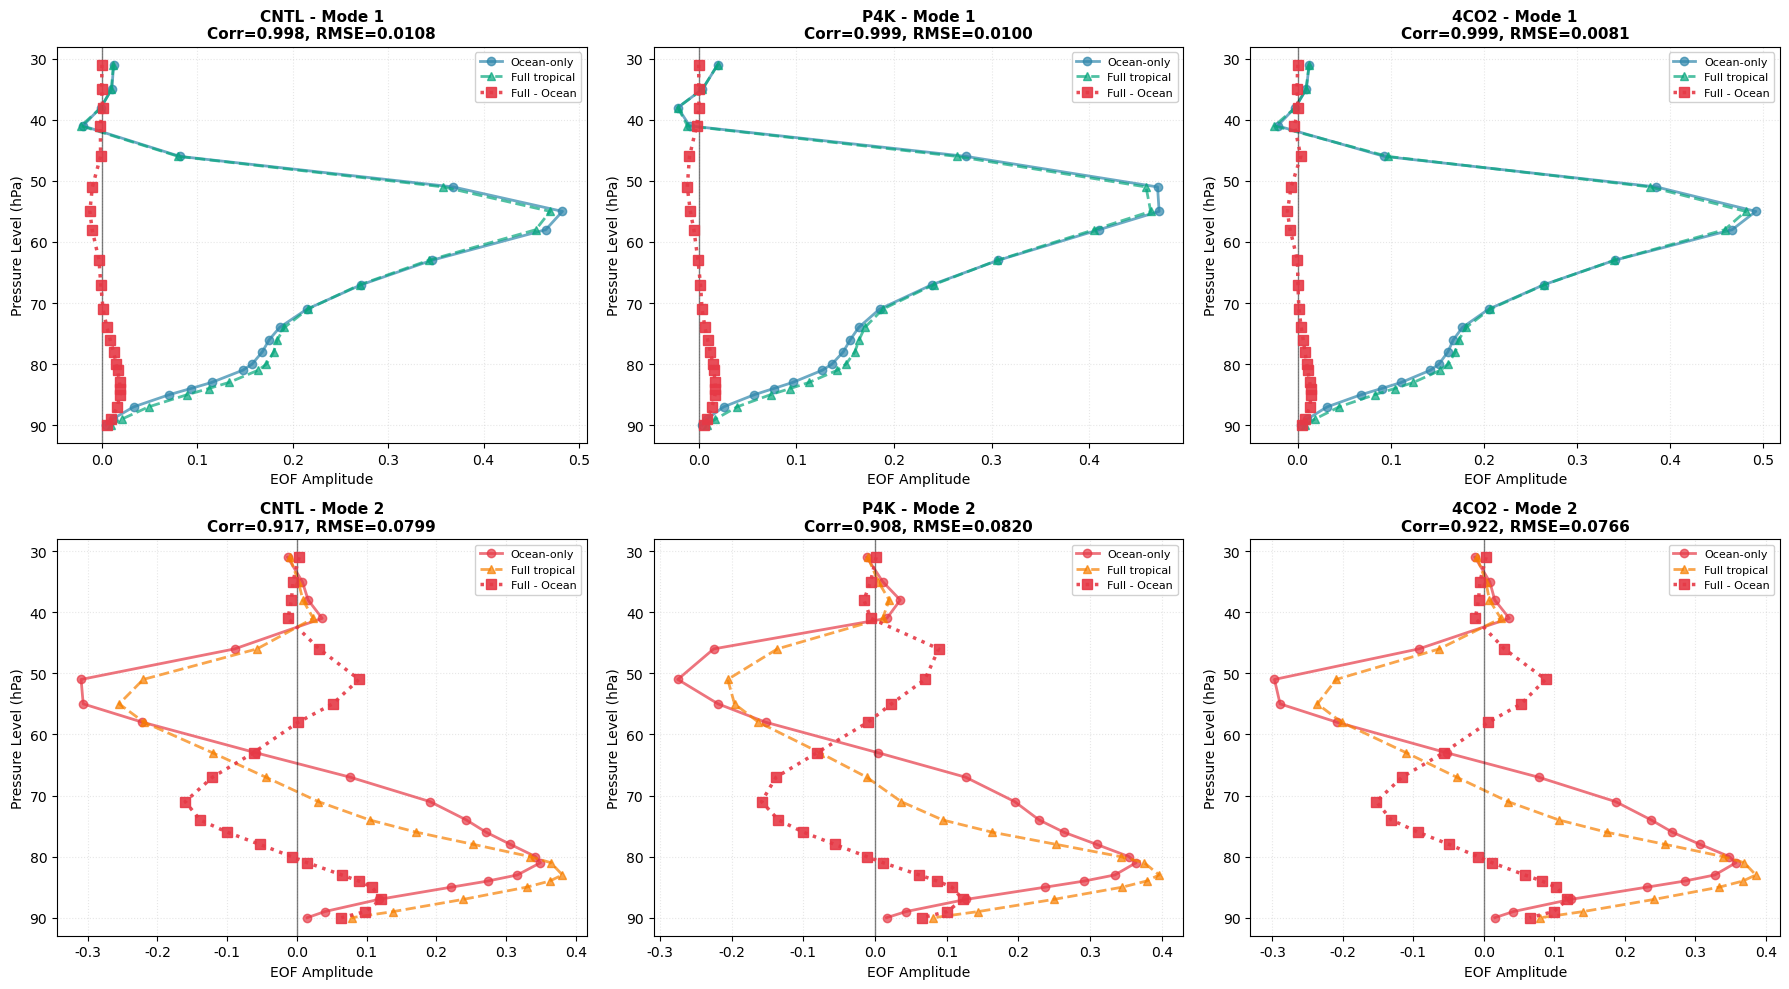

In [33]:
# Create difference plots for better visualization
print("="*70)
print("CREATING DIFFERENCE PLOTS")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for exp_idx, (exp_name, eofs_ocean, eofs_full, var_ocean, var_full) in enumerate(experiments):
    for mode_idx in range(2):
        ax = axes[mode_idx, exp_idx]
        
        # Get EOF profiles
        eof_ocean = eofs_ocean.isel(mode=mode_idx)
        eof_full = eofs_full.isel(mode=mode_idx)
        
        # Align signs
        correlation = np.corrcoef(eof_ocean.values, eof_full.values)[0, 1]
        sign_multiplier = 1 if correlation > 0 else -1
        eof_full_aligned = eof_full * sign_multiplier
        
        # Calculate difference
        diff = eof_full_aligned.values - eof_ocean.values
        
        # Plot all three
        ax.plot(eof_ocean.values, eof_ocean.level.values,
                'o-', linewidth=2, markersize=6, color=colors_ocean[mode_idx],
                label='Ocean-only', alpha=0.7)
        ax.plot(eof_full_aligned.values, eof_full_aligned.level.values,
                '^--', linewidth=2, markersize=6, color=colors_full[mode_idx],
                label='Full tropical', alpha=0.7)
        ax.plot(diff, eof_ocean.level.values,
                's:', linewidth=2.5, markersize=7, color='#E63946',
                label='Full - Ocean', alpha=0.9, zorder=3)
        
        # Formatting
        ax.set_title(f'{exp_name} - Mode {mode_idx+1}\n' +
                    f'Corr={correlation:.3f}, RMSE={np.sqrt(np.mean(diff**2)):.4f}',
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('EOF Amplitude', fontsize=10)
        ax.set_ylabel('Pressure Level (hPa)', fontsize=10)
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, linestyle=':')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        ax.legend(fontsize=8, framealpha=0.9, loc='best')

plt.tight_layout()
save_path = os.path.join(figure_save_path, 'eof_ocean_vs_full_differences.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Difference plot saved to: {save_path}")
plt.show()

In [34]:
# Summary statistics table
print("="*80)
print("SUMMARY TABLE: EOF COMPARISON STATISTICS")
print("="*80)

import pandas as pd

# Collect all statistics
summary_data = []

for exp_name, eofs_ocean, eofs_full, var_ocean, var_full in experiments:
    for mode_idx in range(2):
        eof_ocean = eofs_ocean.isel(mode=mode_idx)
        eof_full = eofs_full.isel(mode=mode_idx)
        
        # Align signs
        correlation = np.corrcoef(eof_ocean.values, eof_full.values)[0, 1]
        sign_multiplier = 1 if correlation > 0 else -1
        eof_full_aligned = eof_full * sign_multiplier
        
        # Calculate statistics
        diff = eof_full_aligned.values - eof_ocean.values
        rmse = np.sqrt(np.mean(diff**2))
        mae = np.mean(np.abs(diff))
        max_diff = np.max(np.abs(diff))
        
        summary_data.append({
            'Experiment': exp_name,
            'Mode': mode_idx + 1,
            'Var_Ocean (%)': f"{var_ocean[mode_idx].values*100:.2f}",
            'Var_Full (%)': f"{var_full[mode_idx].values*100:.2f}",
            'Var_Diff (%)': f"{(var_full[mode_idx].values - var_ocean[mode_idx].values)*100:+.2f}",
            'Correlation': f"{correlation:.4f}",
            'RMSE': f"{rmse:.6f}",
            'MAE': f"{mae:.6f}",
            'Max_Diff': f"{max_diff:.6f}"
        })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# Save to CSV
csv_path = os.path.join(DATA_DIR, 'eof_ocean_vs_full_comparison.csv')
df_summary.to_csv(csv_path, index=False)
print(f"\n✅ Summary table saved to: {csv_path}")

print("\n" + "="*80)

SUMMARY TABLE: EOF COMPARISON STATISTICS
Experiment  Mode Var_Ocean (%) Var_Full (%) Var_Diff (%) Correlation     RMSE      MAE Max_Diff
      CNTL     1         64.59        55.30        -9.28      0.9984 0.010752 0.008515 0.018867
      CNTL     2         12.11        18.32        +6.21      0.9168 0.079910 0.063930 0.160136
       P4K     1         67.11        56.80       -10.30      0.9987 0.009991 0.008113 0.016968
       P4K     2         11.03        18.31        +7.29      0.9078 0.082032 0.066140 0.158235
      4CO2     1         65.07        55.90        -9.17      0.9992 0.008066 0.006442 0.014779
      4CO2     2         11.50        17.99        +6.49      0.9222 0.076560 0.061368 0.152633

✅ Summary table saved to: ./processed_data/eof_ocean_vs_full_comparison.csv



CREATING COMPREHENSIVE SUMMARY FIGURE


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✅ Comprehensive comparison figure saved to: ./figures/wa_xeofs/eof_comprehensive_comparison_all_experiments.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

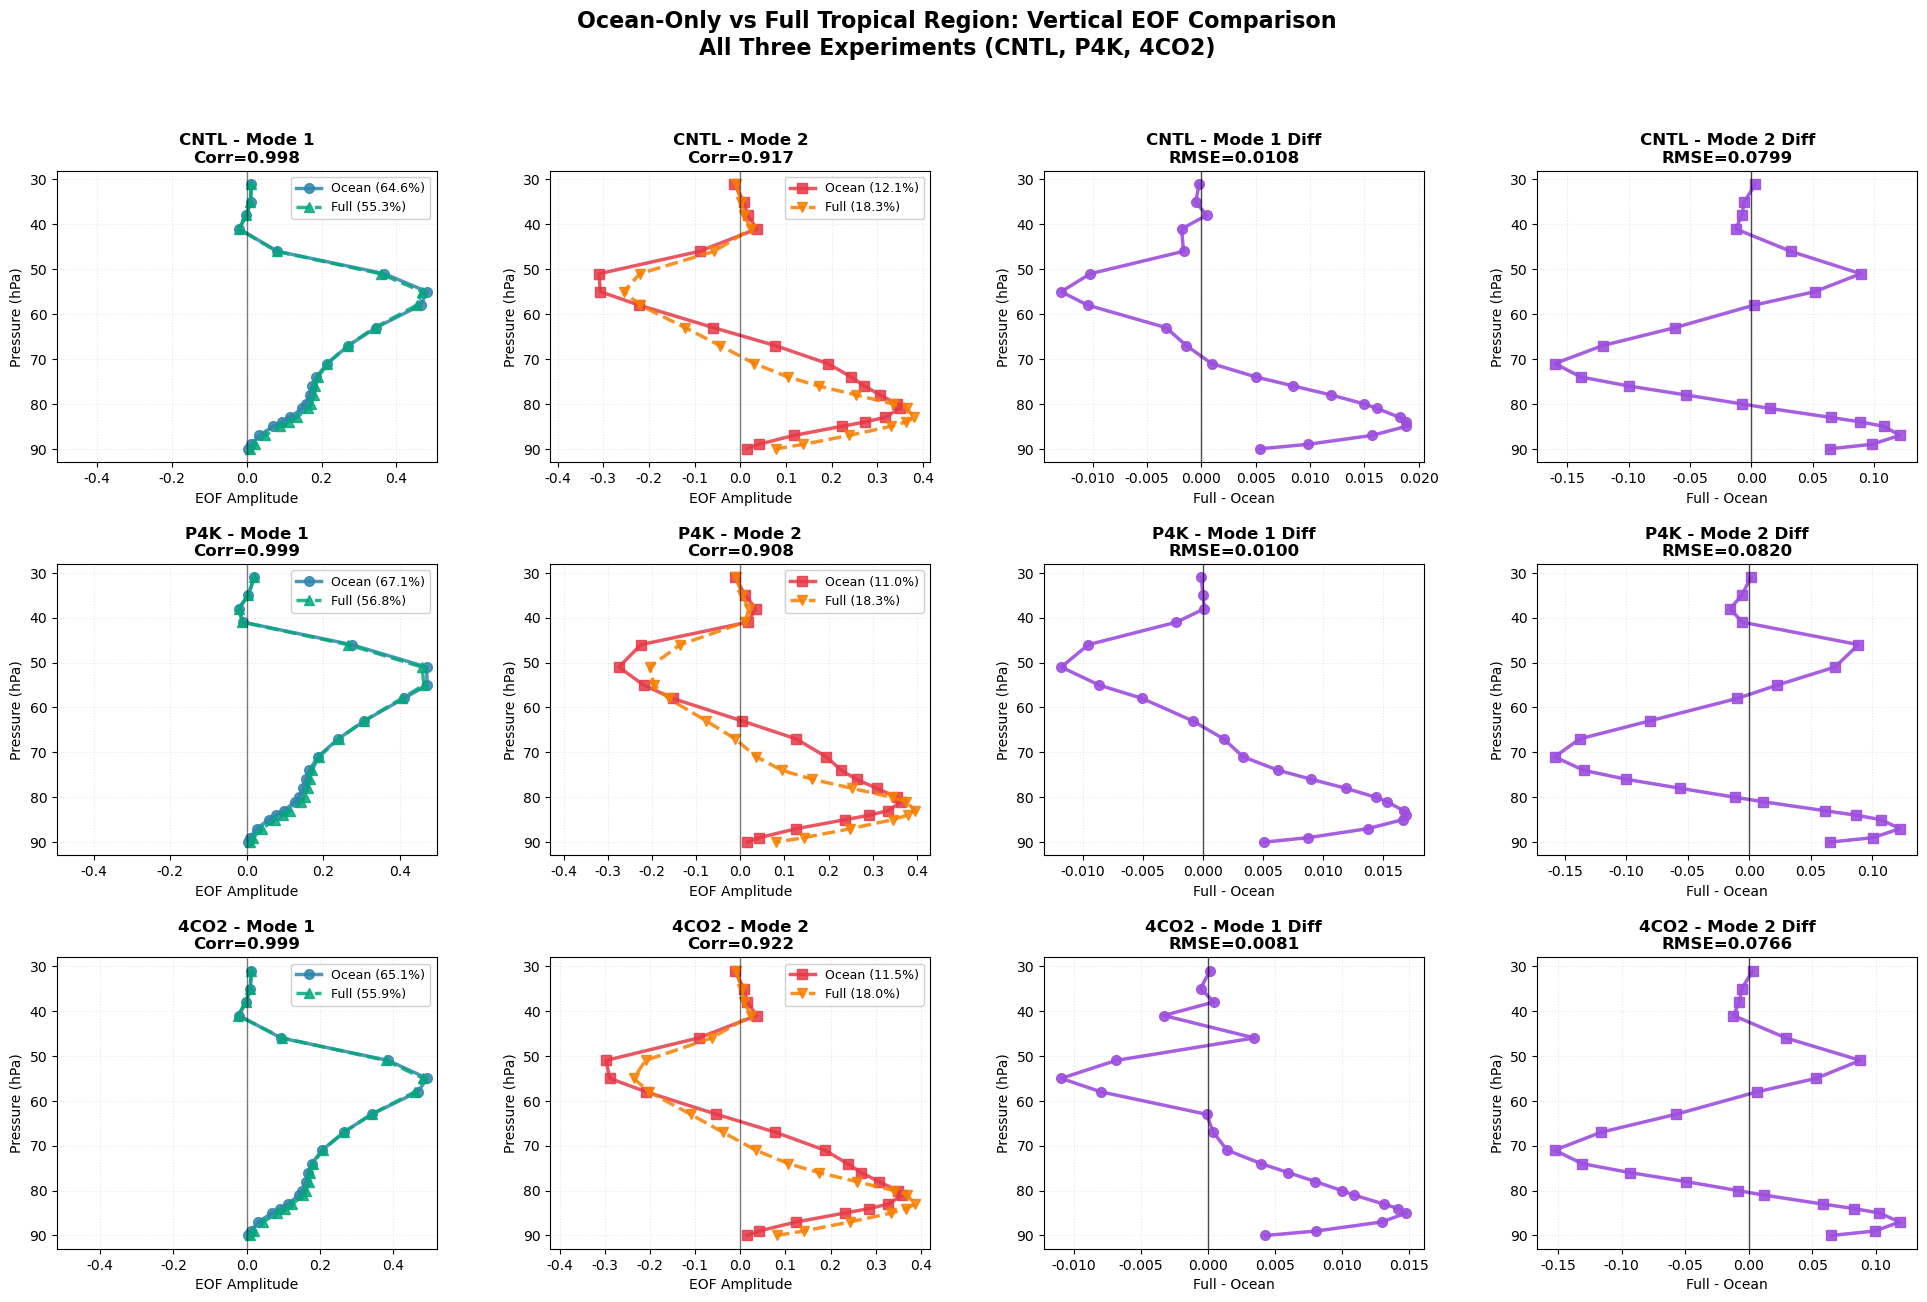

In [35]:
# Create a comprehensive single-page summary figure
print("="*70)
print("CREATING COMPREHENSIVE SUMMARY FIGURE")
print("="*70)

fig = plt.figure(figsize=(24, 14))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# Color scheme
colors = {
    'ocean_m1': '#2E86AB', 'ocean_m2': '#E63946',
    'full_m1': '#06A77D', 'full_m2': '#F77F00',
    'diff': '#9D4EDD'
}

for exp_idx, (exp_name, eofs_ocean, eofs_full, var_ocean, var_full) in enumerate(experiments):
    # Mode 1
    ax1 = fig.add_subplot(gs[exp_idx, 0])
    eof_o_m1 = eofs_ocean.isel(mode=0)
    eof_f_m1 = eofs_full.isel(mode=0)
    
    # Align signs for mode 1
    corr_m1 = np.corrcoef(eof_o_m1.values, eof_f_m1.values)[0, 1]
    sign_m1 = 1 if corr_m1 > 0 else -1
    eof_f_m1_aligned = eof_f_m1 * sign_m1
    
    ax1.plot(eof_o_m1.values, eof_o_m1.level.values, 'o-', 
             linewidth=2.5, markersize=7, color=colors['ocean_m1'], 
             label=f'Ocean ({var_ocean[0].values:.1%})', alpha=0.85)
    ax1.plot(eof_f_m1_aligned.values, eof_f_m1_aligned.level.values, '^--', 
             linewidth=2.5, markersize=7, color=colors['full_m1'], 
             label=f'Full ({var_full[0].values:.1%})', alpha=0.85)
    
    ax1.set_title(f'{exp_name} - Mode 1\nCorr={corr_m1:.3f}', 
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('EOF Amplitude', fontsize=10)
    ax1.set_ylabel('Pressure (hPa)', fontsize=10)
    ax1.invert_yaxis()
    ax1.grid(True, alpha=0.3, linestyle=':')
    ax1.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.5)
    ax1.legend(fontsize=9, framealpha=0.9)
    xlim1 = max(abs(ax1.get_xlim()[0]), abs(ax1.get_xlim()[1]))
    ax1.set_xlim(-xlim1, xlim1)
    
    # Mode 2
    ax2 = fig.add_subplot(gs[exp_idx, 1])
    eof_o_m2 = eofs_ocean.isel(mode=1)
    eof_f_m2 = eofs_full.isel(mode=1)
    
    # Align signs for mode 2
    corr_m2 = np.corrcoef(eof_o_m2.values, eof_f_m2.values)[0, 1]
    sign_m2 = 1 if corr_m2 > 0 else -1
    eof_f_m2_aligned = eof_f_m2 * sign_m2
    
    ax2.plot(eof_o_m2.values, eof_o_m2.level.values, 's-', 
             linewidth=2.5, markersize=7, color=colors['ocean_m2'], 
             label=f'Ocean ({var_ocean[1].values:.1%})', alpha=0.85)
    ax2.plot(eof_f_m2_aligned.values, eof_f_m2_aligned.level.values, 'v--', 
             linewidth=2.5, markersize=7, color=colors['full_m2'], 
             label=f'Full ({var_full[1].values:.1%})', alpha=0.85)
    
    ax2.set_title(f'{exp_name} - Mode 2\nCorr={corr_m2:.3f}', 
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('EOF Amplitude', fontsize=10)
    ax2.set_ylabel('Pressure (hPa)', fontsize=10)
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.3, linestyle=':')
    ax2.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.5)
    ax2.legend(fontsize=9, framealpha=0.9)
    xlim2 = max(abs(ax2.get_xlim()[0]), abs(ax2.get_xlim()[1]))
    ax2.set_xlim(-xlim2, xlim2)
    
    # Difference plot - Mode 1
    ax3 = fig.add_subplot(gs[exp_idx, 2])
    diff_m1 = eof_f_m1_aligned.values - eof_o_m1.values
    rmse_m1 = np.sqrt(np.mean(diff_m1**2))
    
    ax3.plot(diff_m1, eof_o_m1.level.values, 'o-', 
             linewidth=2.5, markersize=7, color=colors['diff'], alpha=0.9)
    ax3.set_title(f'{exp_name} - Mode 1 Diff\nRMSE={rmse_m1:.4f}', 
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Full - Ocean', fontsize=10)
    ax3.set_ylabel('Pressure (hPa)', fontsize=10)
    ax3.invert_yaxis()
    ax3.grid(True, alpha=0.3, linestyle=':')
    ax3.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.7)
    
    # Difference plot - Mode 2
    ax4 = fig.add_subplot(gs[exp_idx, 3])
    diff_m2 = eof_f_m2_aligned.values - eof_o_m2.values
    rmse_m2 = np.sqrt(np.mean(diff_m2**2))
    
    ax4.plot(diff_m2, eof_o_m2.level.values, 's-', 
             linewidth=2.5, markersize=7, color=colors['diff'], alpha=0.9)
    ax4.set_title(f'{exp_name} - Mode 2 Diff\nRMSE={rmse_m2:.4f}', 
                  fontsize=12, fontweight='bold')
    ax4.set_xlabel('Full - Ocean', fontsize=10)
    ax4.set_ylabel('Pressure (hPa)', fontsize=10)
    ax4.invert_yaxis()
    ax4.grid(True, alpha=0.3, linestyle=':')
    ax4.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.7)

# Add overall title
fig.suptitle('Ocean-Only vs Full Tropical Region: Vertical EOF Comparison\n' +
             'All Three Experiments (CNTL, P4K, 4CO2)', 
             fontsize=16, fontweight='bold', y=0.995)

save_path = os.path.join(figure_save_path, 'eof_comprehensive_comparison_all_experiments.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Comprehensive comparison figure saved to: {save_path}")
plt.show()